In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M (Mine) -> 1, R (Rock) -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]

# Scale features
scaler = StandardScaler()
X_sonar_scaled = scaler.fit_transform(X_sonar)

print("Standardized features shape:", X_sonar_scaled.shape)


Standardized features shape: (208, 60)


In [2]:
from sklearn.decomposition import PCA

# Apply PCA to preserve 90% of total variance
pca_90 = PCA(n_components=0.90, random_state=42)
X_pca_90 = pca_90.fit_transform(X_sonar_scaled)

print("Original dimensions count:", X_sonar_scaled.shape[1])
print("Reduced dimensions count (to preserve 90% variance):", X_pca_90.shape[1])


Original dimensions count: 60
Reduced dimensions count (to preserve 90% variance): 22


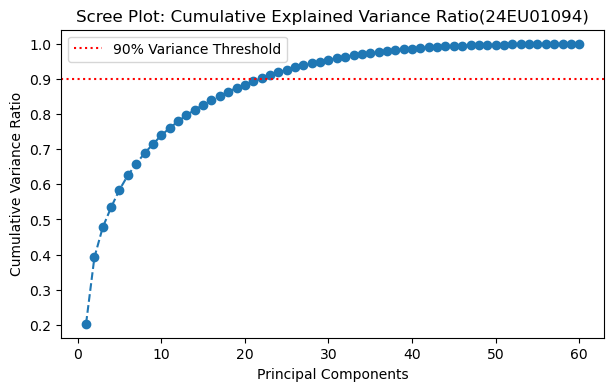

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Fit full PCA to compute complete variance ratios
pca_full = PCA(random_state=42)
pca_full.fit(X_sonar_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.title("Scree Plot: Cumulative Explained Variance Ratio(24EU01094)")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.show()
